In [38]:
#Author: Angel Diaz-Nova, Ricardo Hernandez, Nataliia Padilla
%pip install pandas requests textblob wordcloud newsapi num2words haversine tabulate selenium webdriver_manager
#TODO: VSCode requires the use of % instead of !. This should be changed back before submission.
#TODO: Run one last time before submission. Make sure to try running in Colab
import requests #downloads zip file from webpage
import pandas as pd
import matplotlib.pyplot as plt
import zipfile #extracts csv from zip
import io #allows treat downloaded data as a file object
import seaborn as sns
import time#allows for the program to pause to avoid API rate limits
from textblob import TextBlob # will be used to analyse news from the internet
from wordcloud import WordCloud# to create a word cloud of words mostly used in the articles
from haversine import haversine, Unit #to measure distance between Capital Bikeshare stations and public transit stations
from tabulate import tabulate #Used to print table
import numpy as np # need this for median
from num2words import num2words # need to analyse the words in the news

Note: you may need to restart the kernel to use updated packages.


In [39]:
#Author: Nataliia Padilla
web = ['https://s3.amazonaws.com/capitalbikeshare-data/202005-capitalbikeshare-tripdata.zip', 
       'https://s3.amazonaws.com/capitalbikeshare-data/202006-capitalbikeshare-tripdata.zip', 
       'https://s3.amazonaws.com/capitalbikeshare-data/202007-capitalbikeshare-tripdata.zip', 
       'https://s3.amazonaws.com/capitalbikeshare-data/202008-capitalbikeshare-tripdata.zip', 
       'https://s3.amazonaws.com/capitalbikeshare-data/202009-capitalbikeshare-tripdata.zip', 
       'https://s3.amazonaws.com/capitalbikeshare-data/202010-capitalbikeshare-tripdata.zip', 
       'https://s3.amazonaws.com/capitalbikeshare-data/202011-capitalbikeshare-tripdata.zip', 
       'https://s3.amazonaws.com/capitalbikeshare-data/202012-capitalbikeshare-tripdata.zip', 
       'https://s3.amazonaws.com/capitalbikeshare-data/202101-capitalbikeshare-tripdata.zip', 
       'https://s3.amazonaws.com/capitalbikeshare-data/202102-capitalbikeshare-tripdata.zip', 
       'https://s3.amazonaws.com/capitalbikeshare-data/202103-capitalbikeshare-tripdata.zip', 
       'https://s3.amazonaws.com/capitalbikeshare-data/202104-capitalbikeshare-tripdata.zip', 
       'https://s3.amazonaws.com/capitalbikeshare-data/202105-capitalbikeshare-tripdata.zip', 
       'https://s3.amazonaws.com/capitalbikeshare-data/202106-capitalbikeshare-tripdata.zip', 
       'https://s3.amazonaws.com/capitalbikeshare-data/202107-capitalbikeshare-tripdata.zip', 
       'https://s3.amazonaws.com/capitalbikeshare-data/202108-capitalbikeshare-tripdata.zip', 
       'https://s3.amazonaws.com/capitalbikeshare-data/202109-capitalbikeshare-tripdata.zip', 
       'https://s3.amazonaws.com/capitalbikeshare-data/202110-capitalbikeshare-tripdata.zip', 
       'https://s3.amazonaws.com/capitalbikeshare-data/202111-capitalbikeshare-tripdata.zip', 
       'https://s3.amazonaws.com/capitalbikeshare-data/202112-capitalbikeshare-tripdata.zip', 
       'https://s3.amazonaws.com/capitalbikeshare-data/202201-capitalbikeshare-tripdata.zip', 
       'https://s3.amazonaws.com/capitalbikeshare-data/202202-capitalbikeshare-tripdata.zip', 
       'https://s3.amazonaws.com/capitalbikeshare-data/202203-capitalbikeshare-tripdata.zip', 
       'https://s3.amazonaws.com/capitalbikeshare-data/202204-capitalbikeshare-tripdata.zip', 
       'https://s3.amazonaws.com/capitalbikeshare-data/202205-capitalbikeshare-tripdata.zip', 
       'https://s3.amazonaws.com/capitalbikeshare-data/202206-capitalbikeshare-tripdata.zip', 
       'https://s3.amazonaws.com/capitalbikeshare-data/202207-capitalbikeshare-tripdata.zip', 
       'https://s3.amazonaws.com/capitalbikeshare-data/202208-capitalbikeshare-tripdata.zip', 
       'https://s3.amazonaws.com/capitalbikeshare-data/202209-capitalbikeshare-tripdata.zip', 
       'https://s3.amazonaws.com/capitalbikeshare-data/202210-capitalbikeshare-tripdata.zip', 
       'https://s3.amazonaws.com/capitalbikeshare-data/202211-capitalbikeshare-tripdata.zip', 
       'https://s3.amazonaws.com/capitalbikeshare-data/202212-capitalbikeshare-tripdata.zip', 
       'https://s3.amazonaws.com/capitalbikeshare-data/202301-capitalbikeshare-tripdata.zip', 
       'https://s3.amazonaws.com/capitalbikeshare-data/202302-capitalbikeshare-tripdata.zip', 
       'https://s3.amazonaws.com/capitalbikeshare-data/202303-capitalbikeshare-tripdata.zip', 
       'https://s3.amazonaws.com/capitalbikeshare-data/202304-capitalbikeshare-tripdata.zip', 
       'https://s3.amazonaws.com/capitalbikeshare-data/202305-capitalbikeshare-tripdata.zip', 
       'https://s3.amazonaws.com/capitalbikeshare-data/202306-capitalbikeshare-tripdata.zip', 
       'https://s3.amazonaws.com/capitalbikeshare-data/202307-capitalbikeshare-tripdata.zip', 
       'https://s3.amazonaws.com/capitalbikeshare-data/202308-capitalbikeshare-tripdata.zip', 
       'https://s3.amazonaws.com/capitalbikeshare-data/202309-capitalbikeshare-tripdata.zip', 
       'https://s3.amazonaws.com/capitalbikeshare-data/202310-capitalbikeshare-tripdata.zip', 
       'https://s3.amazonaws.com/capitalbikeshare-data/202311-capitalbikeshare-tripdata.zip', 
       'https://s3.amazonaws.com/capitalbikeshare-data/202312-capitalbikeshare-tripdata.zip', 
       'https://s3.amazonaws.com/capitalbikeshare-data/202401-capitalbikeshare-tripdata.zip', 
       'https://s3.amazonaws.com/capitalbikeshare-data/202402-capitalbikeshare-tripdata.zip', 
       'https://s3.amazonaws.com/capitalbikeshare-data/202403-capitalbikeshare-tripdata.zip', 
       'https://s3.amazonaws.com/capitalbikeshare-data/202404-capitalbikeshare-tripdata.zip', 
       'https://s3.amazonaws.com/capitalbikeshare-data/202405-capitalbikeshare-tripdata.zip', 
       'https://s3.amazonaws.com/capitalbikeshare-data/202406-capitalbikeshare-tripdata.zip', 
       'https://s3.amazonaws.com/capitalbikeshare-data/202407-capitalbikeshare-tripdata.zip', 
       'https://s3.amazonaws.com/capitalbikeshare-data/202408-capitalbikeshare-tripdata.zip', 
       'https://s3.amazonaws.com/capitalbikeshare-data/202409-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202410-capitalbikeshare-tripdata.zip', 
       'https://s3.amazonaws.com/capitalbikeshare-data/202411-capitalbikeshare-tripdata.zip',
      ]
   
df_list = [] #adding each file as a dataframe to a list

In [ ]:
#Author: Nataliia Padilla
#This cell might take a while, you're downloading 16million lines of data
#Just let the program do it's thing and ensure you have sufficient memory available
for url in web:
    response = requests.get(url) #downloaded zip file from web
    if response.status_code == 200:
        with zipfile.ZipFile(io.BytesIO(response.content)) as zip_file: #extracting the data
            for filename in zip_file.namelist():
                #if filename.endwith('.csv'):
                with zip_file.open(filename) as f:
                    df_1 = pd.read_csv(f, encoding='ISO-8859-1', low_memory=False) # there was some error in the columns (missmatch of value types), so we used special encoding
                    df_list.append(df_1)
    else:
        print(f'Failed to download the ZIP file from {url} . Status code ', response.status_code)
df = pd.concat(df_list, ignore_index = True)
print(df)
#idk what those last columns are about, probably can just delete
df = df.drop(['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2'], axis=1)

In [9]:
#Author: Angel Diaz-Nova, Ricardo Hernandez, Nataliia Padilla
#Convert 'started_at' and 'ended_at' to datetime
df['started_at'] = pd.to_datetime(df['started_at'], format='ISO8601')
df['ended_at'] = pd.to_datetime(df['ended_at'], format='ISO8601')

#Calculate additional columns
#TODO: Check if anyone is using these columns before we submit. If no one is using them, removing would be best
#for memory savings
df['Year'] = df['started_at'].dt.year
df['Month'] = df['started_at'].dt.month 

#Calculate ride length
df['Ride Length'] = df['ended_at'] - df['started_at']
df['Ride Length_min'] = pd.to_timedelta(df['Ride Length']).dt.seconds/60

#Calculate if during the ride time a fee was incurred
df['Fee'] = df['Ride Length_min'] > 30 # Rides over 30 minutes incur a fee

In [6]:
df.head() # Testing to see if new column appears and indicates the right logic

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,Year,Month,Ride Length,Ride Length_min,Fine
0,946D42AD89539210,docked_bike,2020-05-30 17:25:29,2020-05-31 18:25:22,Anacostia Library,31804,11th & H St NE,31614.0,38.865784,-76.978400,38.899983,-76.991383,casual,2020.0,5.0,1 days 00:59:53,59.883333,True
1,CC46FAAB662B8613,docked_bike,2020-05-09 14:42:04,2020-05-09 15:06:33,10th & E St NW,31256,21st St & Constitution Ave NW,31261.0,38.895914,-77.026064,38.892459,-77.046567,member,2020.0,5.0,0 days 00:24:29,24.483333,False
2,72F00B2FB833D6ED,docked_bike,2020-05-24 17:27:19,2020-05-24 17:43:51,Connecticut Ave & Newark St NW / Cleveland Park,31305,12th & U St NW,31268.0,38.934267,-77.057979,38.916787,-77.028139,member,2020.0,5.0,0 days 00:16:32,16.533333,False
3,4DFBE6AED989DF35,docked_bike,2020-05-27 15:29:52,2020-05-27 15:47:13,Connecticut Ave & Newark St NW / Cleveland Park,31305,14th & Belmont St NW,31119.0,38.934267,-77.057979,38.921074,-77.031887,casual,2020.0,5.0,0 days 00:17:21,17.350000,False
4,1AAFE6B4331AB9DF,docked_bike,2020-05-31 14:06:03,2020-05-31 14:30:30,Georgia Ave & Morton St NW,31419,17th & K St NW,31213.0,38.932128,-77.023500,38.902760,-77.038630,casual,2020.0,5.0,0 days 00:24:27,24.450000,False


In [7]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18034467 entries, 0 to 18034466
Data columns (total 18 columns):
 #   Column              Dtype          
---  ------              -----          
 0   ride_id             object         
 1   rideable_type       object         
 2   started_at          datetime64[ns] 
 3   ended_at            datetime64[ns] 
 4   start_station_name  object         
 5   start_station_id    object         
 6   end_station_name    object         
 7   end_station_id      object         
 8   start_lat           float64        
 9   start_lng           float64        
 10  end_lat             float64        
 11  end_lng             float64        
 12  member_casual       object         
 13  Year                float64        
 14  Month               float64        
 15  Ride Length         timedelta64[ns]
 16  Ride Length_min     float64        
 17  Fine                bool           
dtypes: bool(1), datetime64[ns](2), float64(7), object(7), timede

ride_id                    11
rideable_type              11
started_at                 11
ended_at                   11
start_station_name    1899785
start_station_id      1899785
end_station_name      2022773
end_station_id        2023828
start_lat                  21
start_lng                  21
end_lat                 27219
end_lng                 27219
member_casual              11
Year                       11
Month                      11
Ride Length                11
Ride Length_min            11
Fine                        0
dtype: int64

## Exploring Inferential Questions Using Capital Bikeshare

# Angel Diaz-Nova

Overview:

1) Supporting awareness of fees based on ride time

   - How many riders have incurred a fee because exceeding the time limit?
   - Can riders like 'Members' advocate for an increased time limit?
  
2) Providing clarity on bike availibility

   -  How many bikes are available across all stations?
   -  Which stations have the most?
   -  Are there any interesting trends in regards to bike availibility?

## First Section

# Awareness of Fees 

For logistic reasons, any user who'd like to cycle say to work, will have to be weary of paying incurred fees. This is based on the time limit that is exerted for every ride. To clarify, there is a rate of charge every ride, but if you haave access to the day or membership pass then the first 45 minutes are free of charge.

In [ ]:
# Angel Diaz-Nova
Total_fee = df['Fee'].sum()
print(f"Total Incurred Fees: {Total_fee}")

Fees_user = df[df['Fee']].groupby('member_casual')['Fee'].count()
print("Breadown Based On User Status:")
print(Fees_user.to_frame(name = "Number of Incurred Fees").reset_index().to_string(index = False))

Total Incurred Fines: 2318857
Breadown Based On User Status:
member_casual  Number of Incurred Fees
       casual                  1652277
       member                   666580


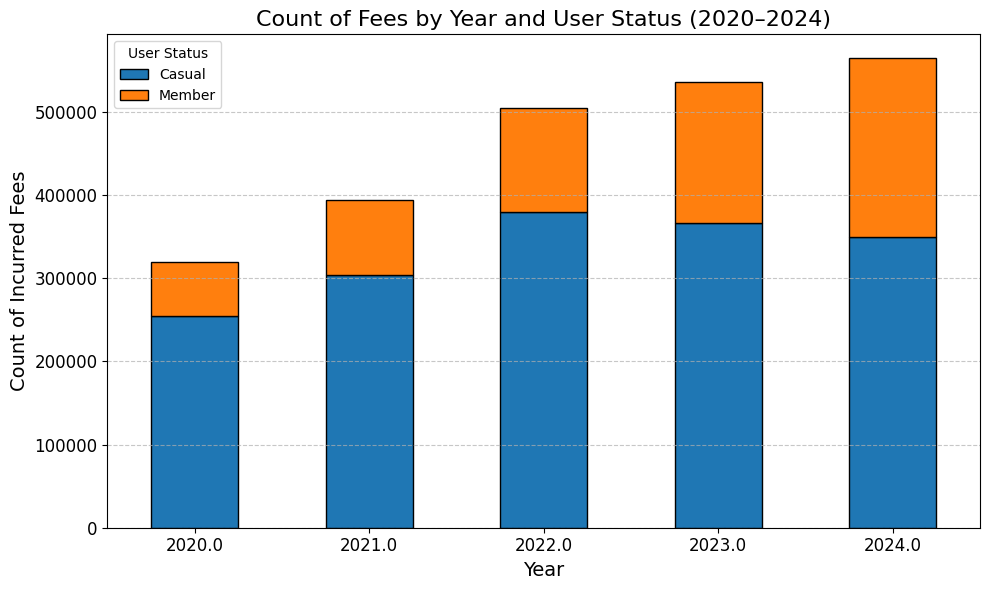

In [ ]:
# Angel Diaz-Nova
Yes_fee = df[df['Fee']] # Filter for rows that only indicate 'True' logic

# Count Fees by year and member_casual
Group_fee = Yes_fee.groupby(['Year', 'member_casual']).size().unstack(fill_value=0)

Group_fee.plot(
    kind = 'bar', # Setting to Bar Plot
    stacked = True, # Adjusting to stack bars to differentiate User Status 
    figsize = (10, 6), # Setting figure size
    color = ['#1f77b4', '#ff7f0e'],  # Colors for casual and member
    edgecolor = 'black' # Adding black edges
)

plt.title('Count of Fees by Year and User Status (2020–2024)', fontsize = 16) # Title of plot
plt.xlabel('Year', fontsize = 14) # Label for X-axis
plt.ylabel('Count of Incurred Fees', fontsize = 14) # Label for Y-Axis
plt.legend(title = 'User Status', labels = ['Casual', 'Member']) # Legend to describe the user status
plt.xticks(rotation = 0, fontsize = 12) # # Adjusting font size and adding rotation of X-Axis label
plt.yticks(fontsize = 12) # Adjusting font size of Y-Axis label
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7) # Adding a horizontal grid

# Show the plot
plt.tight_layout() # Adding a tight layout to ensure no overlapping
plt.show() # Display Plot

Q: How many riders, members or casuals alike pay a fee? Meaning the bike ride exceeded the 30 minute time limit. Also, is there a difference between both groups? 

A: As predicted beforehand, casual riders are more 'prone' to incurred fees. There have been over 2,205,768 labelled as 'True,' meaning over 2 million reported rides have led to an incurred fees due to exceeding the time limit of 45 minutes. More specifically, as the amount of rides grew over the years, so did the the case count of incurred fees - seen very profoundly, but with a slight decrease from 2023 to 2024. But, this can change given the year is still yet to end. 

Following that up what if the context was reversed. Within the conFees of this thinking, is it possible to configure a simple, yet perhaps complex contrast to the past question. But this time advocate a new policy or arrangement for a certain group?

In [12]:
# Angel Diaz-Nova
No_fee = len(df) - Total_fee
print(f"Rides With No Incurred Fees: {No_fee}")

No_fee_user = df[df['Fee'] == False].groupby('member_casual')['Fee'].count()

# Print the breakdown based on user status (member/casual)
print("Breakdown Based on User Status (No Fee):")
print(No_fee_user.to_frame(name = "Number of Rides Without Incurred Fees").reset_index().to_string(index = False))

Rides With No Incurred Fees: 15715610
Breakdown Based on User Status (No Fee):
member_casual  Number of Rides Without Incurred Fees
       casual                                5276358
       member                               10439241


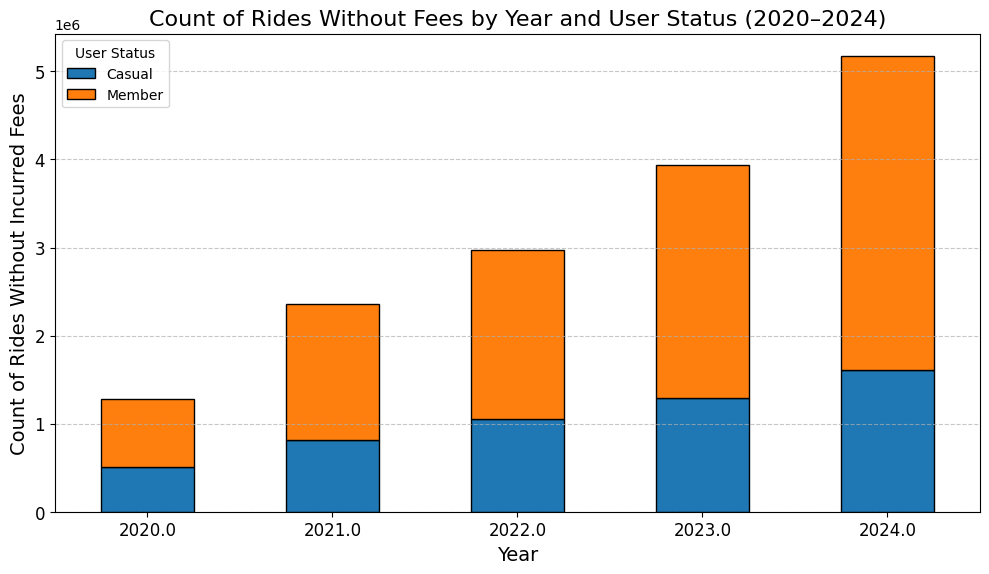

In [13]:
# Angel Diaz-Nova
No_fees = df[df['Fee'] == False] # Filter for rows that only indicate 'False' logic

# Count 'False' cases by year and member_casual
Group_no_fine = No_fees.groupby(['Year', 'member_casual']).size().unstack(fill_value=0)

Group_no_fine.plot(
    kind = 'bar',  # Setting to Bar plot
    stacked = True,  # Adjusting to stack bars to differentiate User Status
    figsize = (10, 6),  # Setting figure size
    color = ['#1f77b4', '#ff7f0e'], # Colors for casual and member 
    edgecolor = 'black' # Adding black edges
)

plt.title('Count of Rides Without Fees by Year and User Status (2020–2024)', fontsize=16) # Title of plot
plt.xlabel('Year', fontsize = 14) # Label for X-Axis
plt.ylabel('Count of Rides Without Incurred Fees', fontsize = 14) # Label for Y-Axis
plt.legend(title = 'User Status', labels = ['Casual', 'Member']) # Legend to describe the user status
plt.xticks(rotation = 0, fontsize = 12) # Adjusting font size and adding rotation of X-Axis label
plt.yticks(fontsize = 12) # Adjusting font size of Y-Axis label
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7) # Adding a horizontal grid

# Show the plot
plt.tight_layout() # Adding a tight layout to ensure no overlaps
plt.show() # Display plot

Q: Similar concept as before with a twist. A small trend was shown previously that rides are increasing over the past four years. Can the inverse of before provide a baseline to advocate for members to earn an extended time limit? 

A: For the sake of argument, the same inferences can be made with the graph and simple count statistic. However, based on the Bereau's message, they are actively showing effort to improve upon their existing policies and programs to the betterment of all Americans who rely on connected transportation networks. To clarify, a clear trend is shown throughout the last four years, that riders with 'Member' status are less likely to incur a fee during their ride. My suggestion would be to include a feature where members are given an extended time limit.

However, say the case is that casual riders are unaware of the possibility of incurred fees - as an advertisement we can suggest for the Bereau of Transportation to appeal to this group to switch to a day pass or annual membership. And, here is the real benefit - the first 45 minutes are free. Yes free! Meaning the real fees do not begin to incur until after the 45 minute span after undocking a bike. 

## Second Section

# Bike Availability

Furthermore, a report from 'Greater Greater Washington' states that micromobility ridership surges in D.C. (District of Colombia) with 3.4 million trips through June. In here, their report captures not simply the unwavering presence of micromobility providers within this region, but more importantly, notices the growth in demand in terms of commute (Micromobility - To travel light from a short mile radius). To further explain, this indicates a related topic to this report, and using Bike Share Research data as a method to clarify impacts on Bike Availability.

In [ ]:
# Angel Diaz-Nova

# List of URLs from Bike Share Research Data Feeds
urls = [
    "https://gbfs.lyft.com/gbfs/1.1/dca-cabi/en/station_status.json",
    "https://gbfs.lyft.com/gbfs/1.1/dca-cabi/en/station_information.json",
]

# Function to fetch data from a URL
def fetch_data(url):
    response = requests.get(url)
    if response.status_code == 200:
        return response.json()
    else:
        print(f"Failed to fetch data from {url}. Status code: {response.status_code}")
        return None

# Fetch data from all URLs
data = {}
for url in urls:
    data[url] = fetch_data(url)

# Extract station information (station names and IDs)
station_info = data[urls[1]].get("data", {}).get("stations", [])

# Create a mapping of station IDs to names
station_id_to_name = {station['station_id']: station['name'] for station in station_info}

# Extract station status (bike availability)
station_status = data[urls[0]].get("data", {}).get("stations", [])

# Map station status with station names
for station in station_status:
    station_id = station.get('station_id')
    station['name'] = station_id_to_name.get(station_id, "Unknown")

# Create a DataFrame for easy analysis
stations_df = pd.DataFrame(station_status)

# Step 1: Convert `last_reported` from Unix timestamp to a readable date
stations_df['last_reported'] = pd.to_datetime(stations_df['last_reported'], unit='s')
print("After converting 'last_reported' to date:\n", stations_df[['last_reported']])

# Step 2: Handle `num_scooters_unavailable` and `num_scooters_available` columns
stations_df['num_scooters_unavailable'] = stations_df['num_scooters_unavailable'].replace(0.0, np.nan)
stations_df['num_scooters_available'] = stations_df['num_scooters_available'].replace(0.0, np.nan)
print("\nAfter replacing 0.0 with NaN in 'num_scooters_*' columns:\n", stations_df[['num_scooters_unavailable', 'num_scooters_available']])

# Step 3: Drop `legacy_id` if not needed
stations_df = stations_df.drop(columns=['legacy_id'])
print("\nAfter dropping 'legacy_id':\n", stations_df.head())

# Step 4: Clean `num_ebikes_available` and `num_bikes_disabled`
stations_df['num_ebikes_available'] = stations_df['num_ebikes_available'].apply(lambda x: x if x >= 0 else np.nan)
stations_df['num_bikes_disabled'] = stations_df['num_bikes_disabled'].apply(lambda x: x if x >= 0 else np.nan)
print("\nAfter cleaning 'num_ebikes_available' and 'num_bikes_disabled':\n", stations_df[['num_ebikes_available', 'num_bikes_disabled']])

# Step 5: Clean `station_id` - ensure it contains valid values (i.e., strings)
stations_df['station_id'] = stations_df['station_id'].apply(lambda x: x if isinstance(x, str) else np.nan)
print("\nAfter cleaning 'station_id':\n", stations_df[['station_id']])

# Step 6: Check binary columns to ensure only 0 or 1
binary_columns = ['is_installed', 'is_renting', 'is_returning']
stations_df[binary_columns] = stations_df[binary_columns].apply(lambda col: col.apply(lambda x: x if x in [0, 1] else np.nan))
print("\nAfter checking binary columns:\n", stations_df[binary_columns])

# Final cleaned DataFrame
print("\nFinal cleaned DataFrame:\n", stations_df)

After converting 'last_reported' to date:
           last_reported
0   2024-12-11 23:33:30
1   2024-12-11 23:33:28
2   2024-12-11 23:33:30
3   2024-12-11 23:33:31
4   2024-12-11 23:33:34
..                  ...
778 2024-12-11 23:35:27
779 2024-12-11 23:35:28
780 2024-12-11 23:35:28
781 2024-12-11 23:35:28
782 2024-12-11 23:35:29

[783 rows x 1 columns]

After replacing 0.0 with NaN in 'num_scooters_*' columns:
      num_scooters_unavailable  num_scooters_available
0                         NaN                     NaN
1                         NaN                     NaN
2                         NaN                     NaN
3                         NaN                     NaN
4                         NaN                     NaN
..                        ...                     ...
778                       NaN                     NaN
779                       NaN                     NaN
780                       NaN                     NaN
781                       NaN                

In [15]:
# Calculate the total number of bikes available across all stations
total_bikes_available = stations_df['num_bikes_available'].sum()

# Calculate the total number of stations
total_stations = len(stations_df)

# Calculate the 25% and 75% quartiles
quartiles = stations_df['num_bikes_available'].quantile([0.25, 0.75])

# Print total bikes, total stations, and quartiles
print(f"Total bikes available across all stations: {total_bikes_available}")
print(f"Total number of stations: {total_stations}")
print(f"25% Quartile: {quartiles[0.25]:.2f}")
print(f"75% Quartile: {quartiles[0.75]:.2f}")

Total bikes available across all stations: 5668
Total number of stations: 783
25% Quartile: 4.00
75% Quartile: 10.00


Q: Considering the growth and using real time data provided by JSON files (Bike Share Open Research), how many bikes are currently available across all stations (Searches in real time when data is loaded in!)? 

A: As of 12/11/2024, the total amount of bikes which are registered as 'available' is 5,818 across 783 stations. And for the sake of argument with the following questions, there is a feature to demonstrate the 25% and 75% quartile as benchmarks using the num_bike_available (Number of docking bikes available). 

From that simple search, there is a deeper analysis awaiting. As mentioned, there are over 5,000 stations, but perhaps there is a possiblity of no bikes being presently available.

In [16]:
# Stations with zero bikes available
stations_no_bikes = stations_df[stations_df['num_bikes_available'] == 0] # Meaning no bikes are present or docked
print("Stations with no bikes available:")
print(stations_no_bikes[['name', 'num_bikes_available']])

Stations with no bikes available:
                                                  name  num_bikes_available
24           Joliet St & MLK Ave SW/Bald Eagle Rec Ctr                    0
32                                       1st & H St NW                    0
66             Wheaton Metro / Georgia Ave & Reedie Dr                    0
88                                       3rd & G St SE                    0
90                            White Oak Transit Center                    0
95                 Merrilee Dr & Lauren Elizabeth Lane                    0
123                                      2nd & G St NE                    0
142                          Briggs Chaney & Castle Dr                    0
220                      18th St & Pennsylvania Ave NW                    0
228                                17th & Upshur St NW                    0
247                    American University East Campus                    0
262                                     13th & U St NW

These stations can be flagged as 'main priority' due to the fact of there being zero activity in terms of availability. 

In [17]:
# Stations with fewer than 4 bikes available
zero_out = stations_df[stations_df['num_bikes_available'] > 0] # To remove stations set at zero - For category purposes
stations_restock = zero_out[zero_out['num_bikes_available'] < 4] # Using the 25% quartile statistic
print("\nStations needing restocking (less than 4 bikes available):")
print(stations_restock[['name', 'num_bikes_available']])


Stations needing restocking (less than 4 bikes available):
                                                name  num_bikes_available
2                             Rhode Island Ave Metro                    2
7                1st & Washington Hospital Center NW                    3
8                             Crescent Rd & Ridge Rd                    3
14                           N Howard St & Taney Ave                    1
16   Vaden Dr & Royal Victoria Dr/Jim Scott Cmty Ctr                    3
..                                               ...                  ...
768                    East West Hwy & Blair Mill Rd                    3
770                                    1st & K St NE                    1
772                                Stanton Square SE                    3
773                            Rhodes St & 16th St N                    1
781                    14th St & Marion Barry Ave SE                    2

[147 rows x 2 columns]


As seen by the large amount of rows, this may not be the best indicator for restocking. However, this can be used to categorize, or flag another group of stations. Thus, these stations will be next to take importance after restocking stations at 'high priority.'

In [18]:
# Find stations with more than 10 bikes available (considered overstocked)
station_overstock = stations_df[stations_df['num_bikes_available'] > 10]  # Using a custom threshold of 10 bikes
print("\nStations considered overstocked (more than 10 bikes available):")
print(station_overstock[['name', 'num_bikes_available']])


Stations considered overstocked (more than 10 bikes available):
                                name  num_bikes_available
6     WAU / Flower Ave & Division St                   14
17            D St & Maryland Ave NE                   11
28        The Mall at Prince Georges                   14
33         Fenton St & New York Ave                    11
45   Columbus Circle / Union Station                   21
..                               ...                  ...
763     13th & O St NW/ Logan Circle                   11
767            3rd & Underwood St NW                   11
769         16th & K St NW/BLM Plaza                   16
771         Potomac Ave & Half St SW                   11
780                   15th & W St NW                   12

[159 rows x 2 columns]


Similar to before, with almost identical findings in terms of rows and columns, but only difference is that the opposite of before is what is true. In other words, stations such as these would be of least importance of stocking.

Q: Which stations have zero or very few bikes available? In addition, are there any stations with no bikes available currently? As well as, which stations have the highest number of bikes available? Can we notice a pattern?

A: If time permitted, I would make a firm list and track the performance in terms of these metrics over time. But as of now, there are three different categories if the Capital Bikeshare would be interested in improving the access of bikes docked throughout multiple stations through the service of Capital Bikeshare. To clarify further, each category provides insight into how to act in an fashionable way to meet the casual and members interests.

Following the theme of this second section, conducting a 'Bike to Dock' ratio which will quantify underutilized or overcrowded stations. Then, can we describe if it can be explained by maintenance issues using the num_bikes_disabled variable.

Q: Which stations have the highest bike-to-dock ratio? Are there any stations where the ratio is zero? Meaning there is no bikes at the time of reporting. 

A: 

# Evaluating Capital Bikeshare Data
## Ricardo Hernandez

#### Questions:
### How does Capital Bikeshare usage change throughout the year?
##### - How does the average trip duration change throughout the year?
##### - How does the number of trips change throughout the year?
### 2. How does Capital Bikeshare usage change throughout the system?
##### - What are the most commonly used Capital Bikeshare stations?
##### - What are the least commonly used Capital Bikeshare stations?
##### - How do transit options differ in the areas surrounding the least and most used stations?
##### - Can any patterns be observed in the names of the least and most used stations?

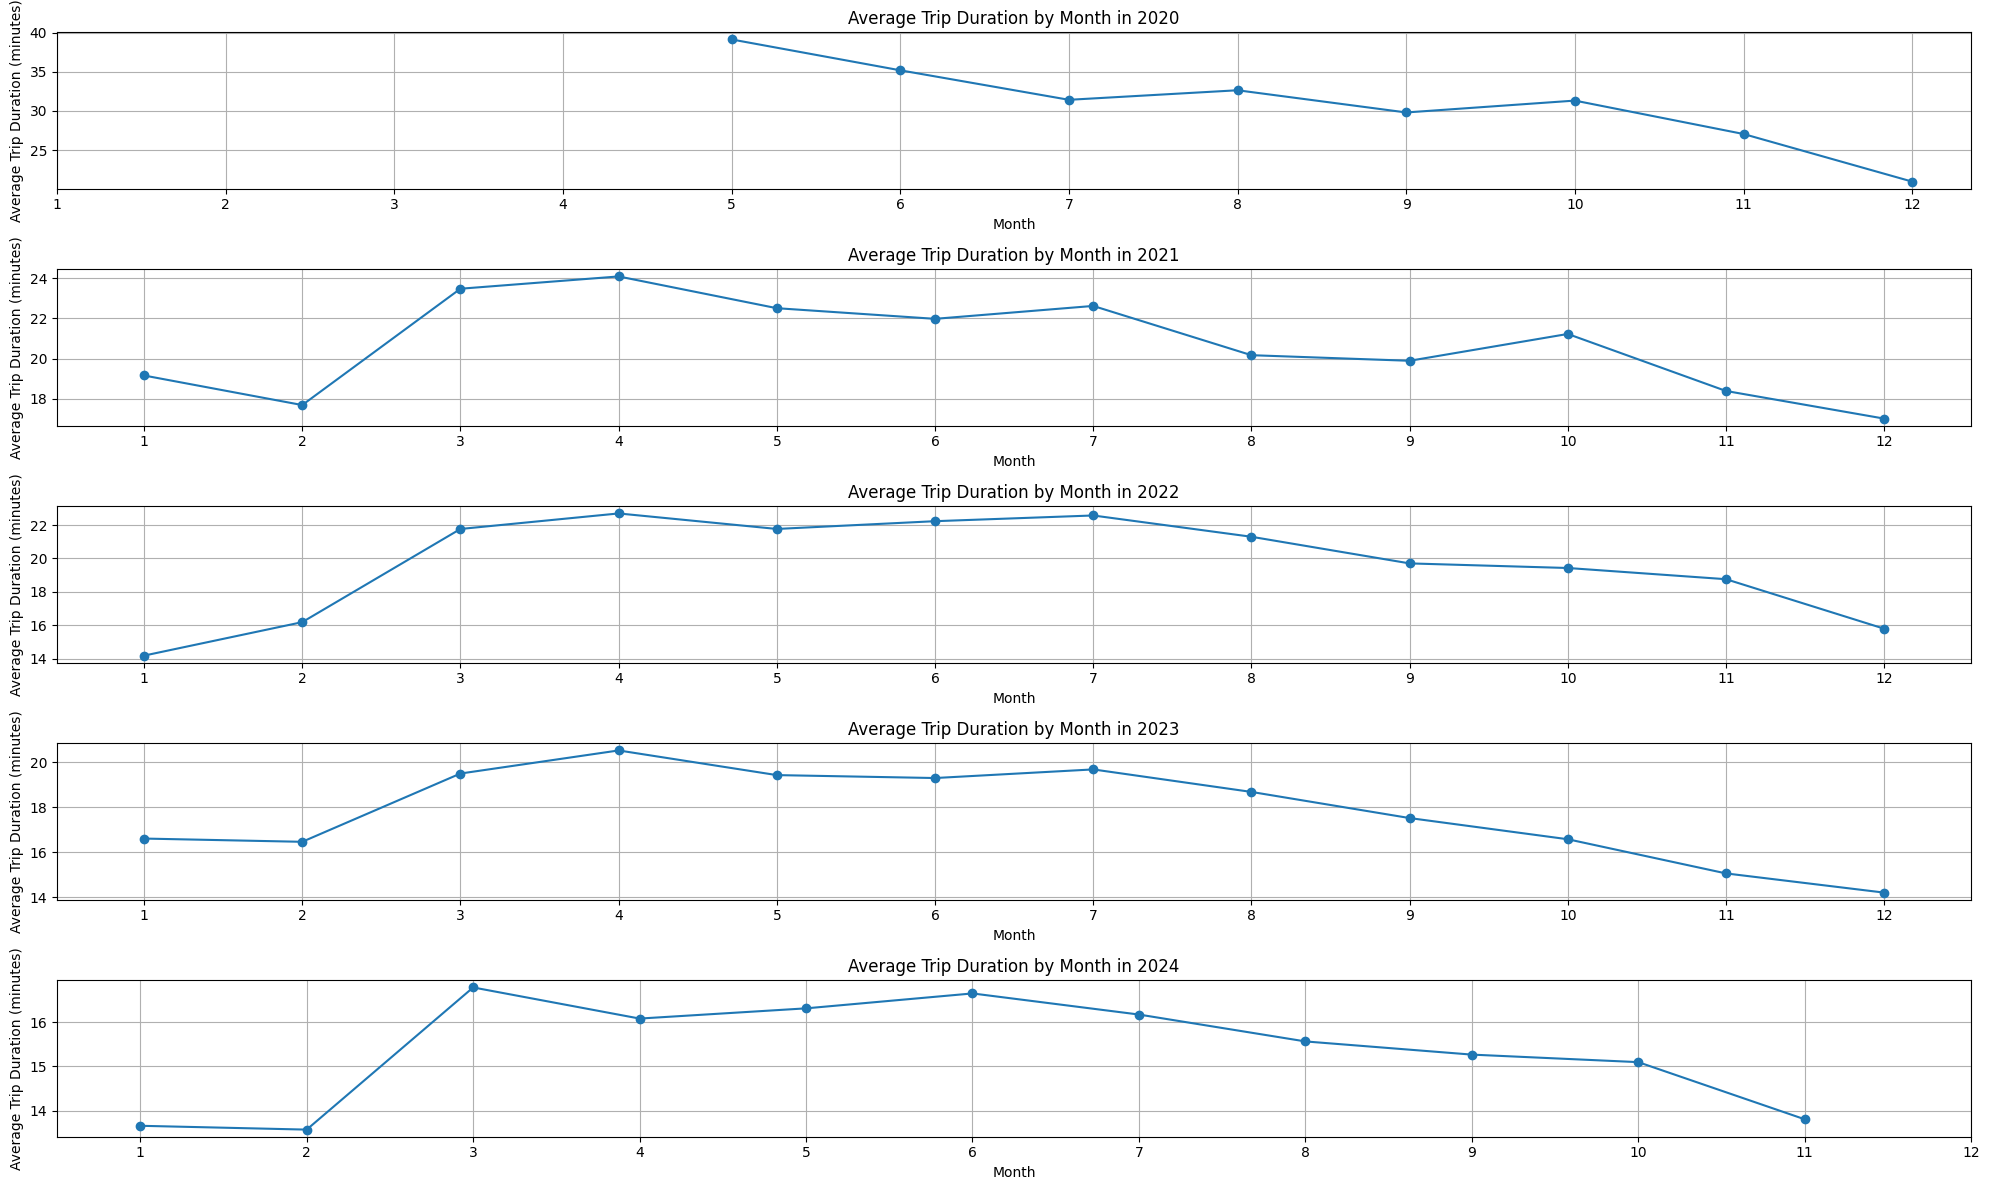

In [ ]:
#Author: Ricardo Hernandez
def plot_average_trip_length(df, year):
    #Plots average trip duration by month in a given year
    #Input: df - the dataframe to analyze
    #Input: The year to analyze
    #Output: a graph showing average trip length for each month in a year

    #Filter for the specified year
    df_year = df[df['Year'] == year]

    #Calculate average trip duration per month
    monthly_average_duration = df_year.groupby('Month')['Ride Length_min'].mean()

    #Plot results
    plt.plot(monthly_average_duration.index, monthly_average_duration.values, marker='o')
    plt.xlabel('Month')
    plt.ylabel('Average Trip Duration (minutes)')
    plt.title(f'Average Trip Duration by Month in {year}')
    plt.xticks(range(1, 13))
    plt.grid(True)

#Create a 5 * 1 figure to hold smaller plots
plt.figure(figsize=(20, 12))

#Plot for 2020
plt.subplot(5, 1, 1)
plot_average_trip_length(df, 2020)

#Plot for 2021
plt.subplot(5, 1, 2)
plot_average_trip_length(df, 2021)

#Plot for 2022
plt.subplot(5, 1, 3)
plot_average_trip_length(df, 2022)

#Plot for 2023
plt.subplot(5, 1, 4)
plot_average_trip_length(df, 2023)

#Plot for 2024
plt.subplot(5, 1, 5)
plot_average_trip_length(df, 2024)

plt.tight_layout()
plt.show()

## Q: How does the average trip duration change throughout the year?
##### A: Trip duration consistently peaks in April while steadily following throughout the winter, reaching its lowest point in December and January. These charts suggest that the peak time for trip duration occurs within April through July. These charts also show that average trip duration has been consistently declining from 2020 - 2024, which may indicate that changes are needed.

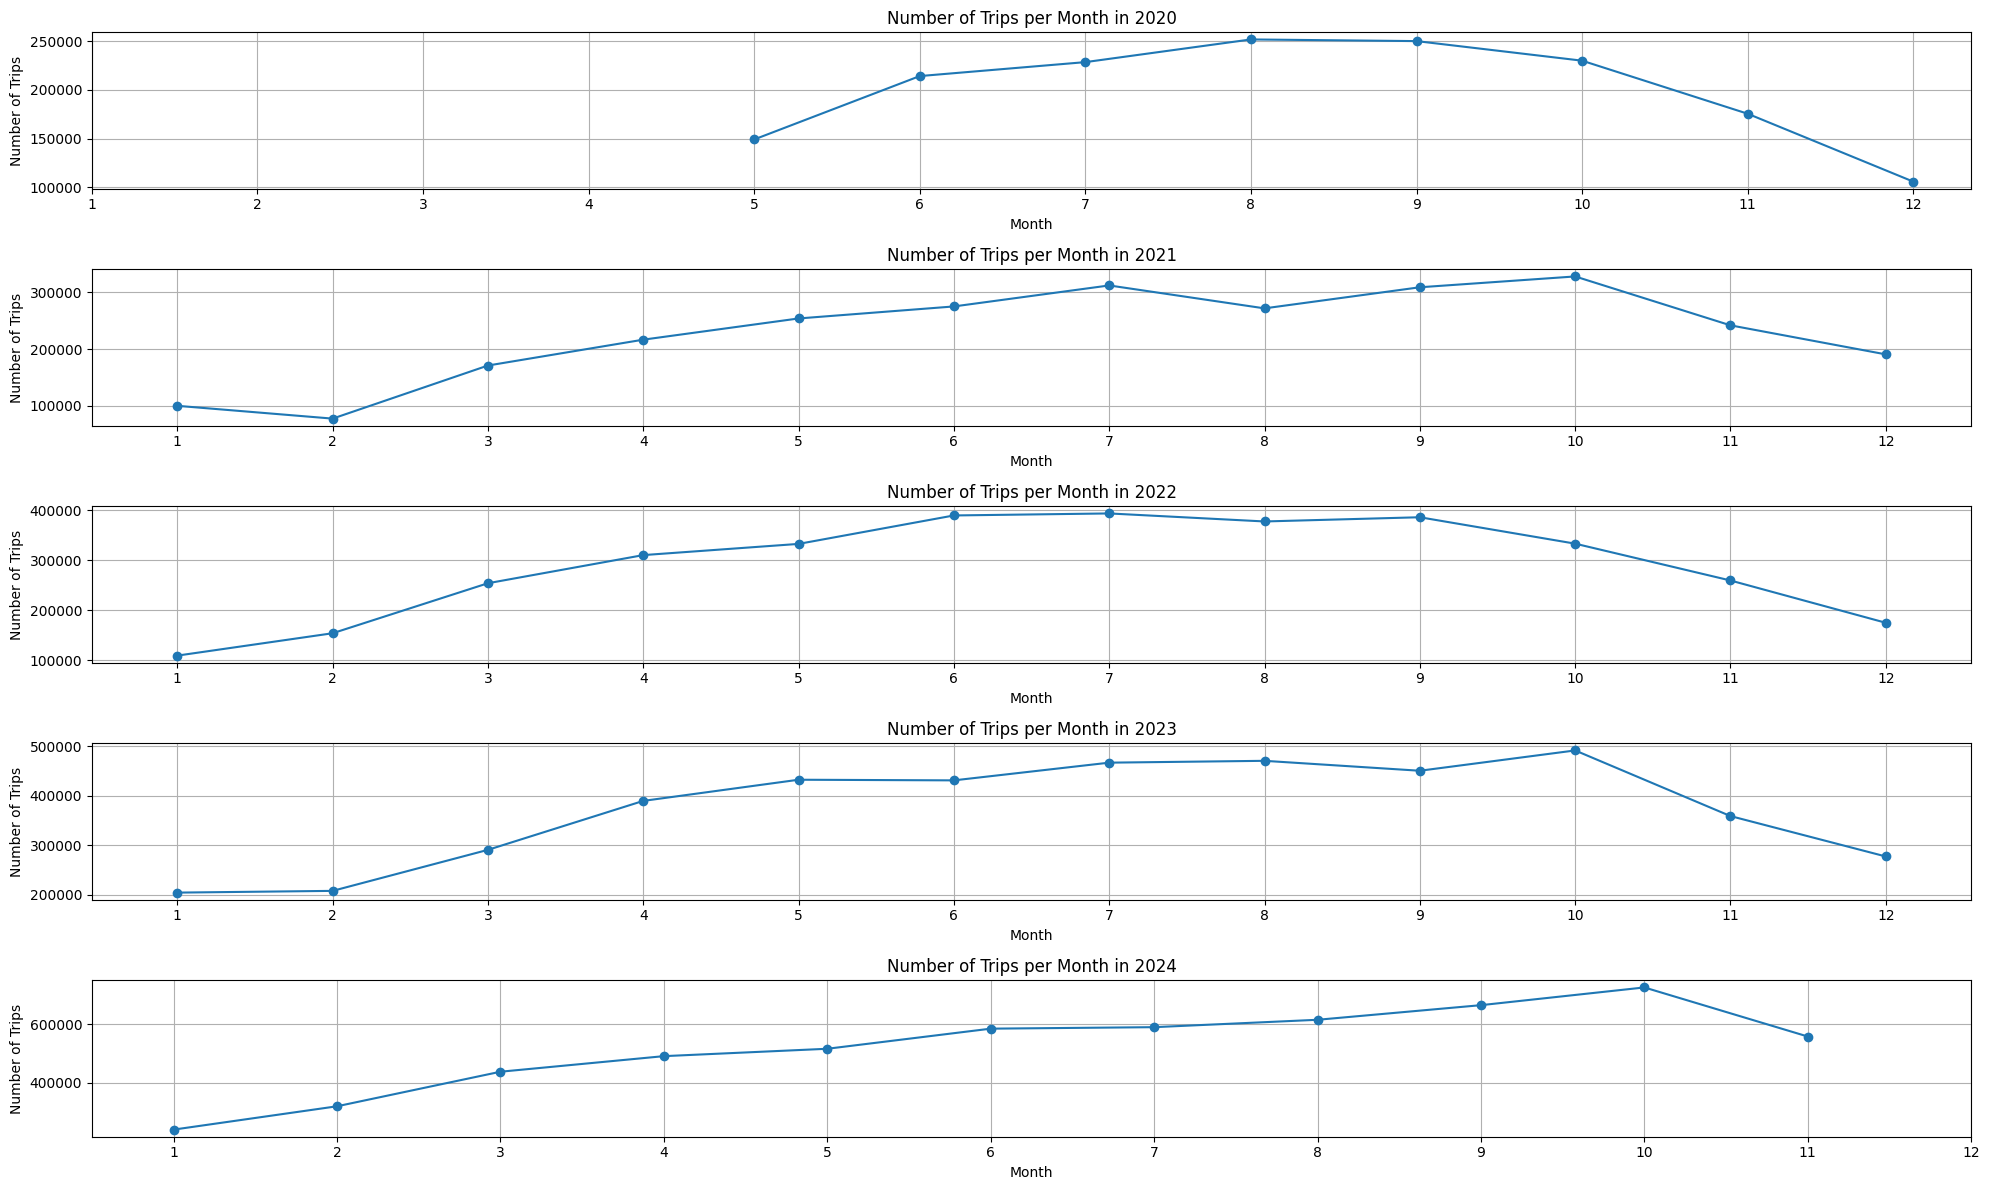

In [ ]:
#Author: Ricardo Hernandez
def plot_monthly_trips(df, year):
    #Plots number of trips taken each month in a given year
    #Input: df - dataframe to analyze
    #Input: year - year to analyze
    #Output: A graph with number of monthly trips in given year

    #Filter by given year
    df_year = df[df['Year'] == year]
    
    #Get months of year
    df_year.loc[:, 'Month'] = df_year['started_at'].dt.month
    
    
    #Count trips in each month
    monthly_trips = df_year.groupby('Month').size()
    
    #Plot results
    plt.plot(monthly_trips.index, monthly_trips.values, marker='o')
    plt.xlabel('Month')
    plt.ylabel('Number of Trips')
    plt.title(f'Number of Trips per Month in {year}')
    plt.xticks(range(1, 13))
    plt.grid(True)

#Create a 5 * 1 figure to hold smaller grids
plt.figure(figsize=(20, 12))

#Plot for 2020
plt.subplot(5, 1, 1)
plot_monthly_trips(df, 2020)

#Plot for 2021
plt.subplot(5, 1, 2)
plot_monthly_trips(df, 2021)

#Plot for 2022
plt.subplot(5, 1, 3)
plot_monthly_trips(df, 2022)

#Plot for 2023
plt.subplot(5, 1, 4)
plot_monthly_trips(df, 2023)

#Plot for 2023
plt.subplot(5, 1, 5)
plot_monthly_trips(df, 2024)

plt.tight_layout()
plt.show()

## Q: How does the number of trips change throughout the year?
##### A: Like trip duration, the total number of trips also steadily declines throughout the winter, picking back up in the summer. Unlike trip duration, the number of trips doesn't start dropping off until later in the year, typically around September or October insetad of immediately after July.

##### This means that although trip duration declines as the year progresses, the total number of trips actually *increases* until about September.

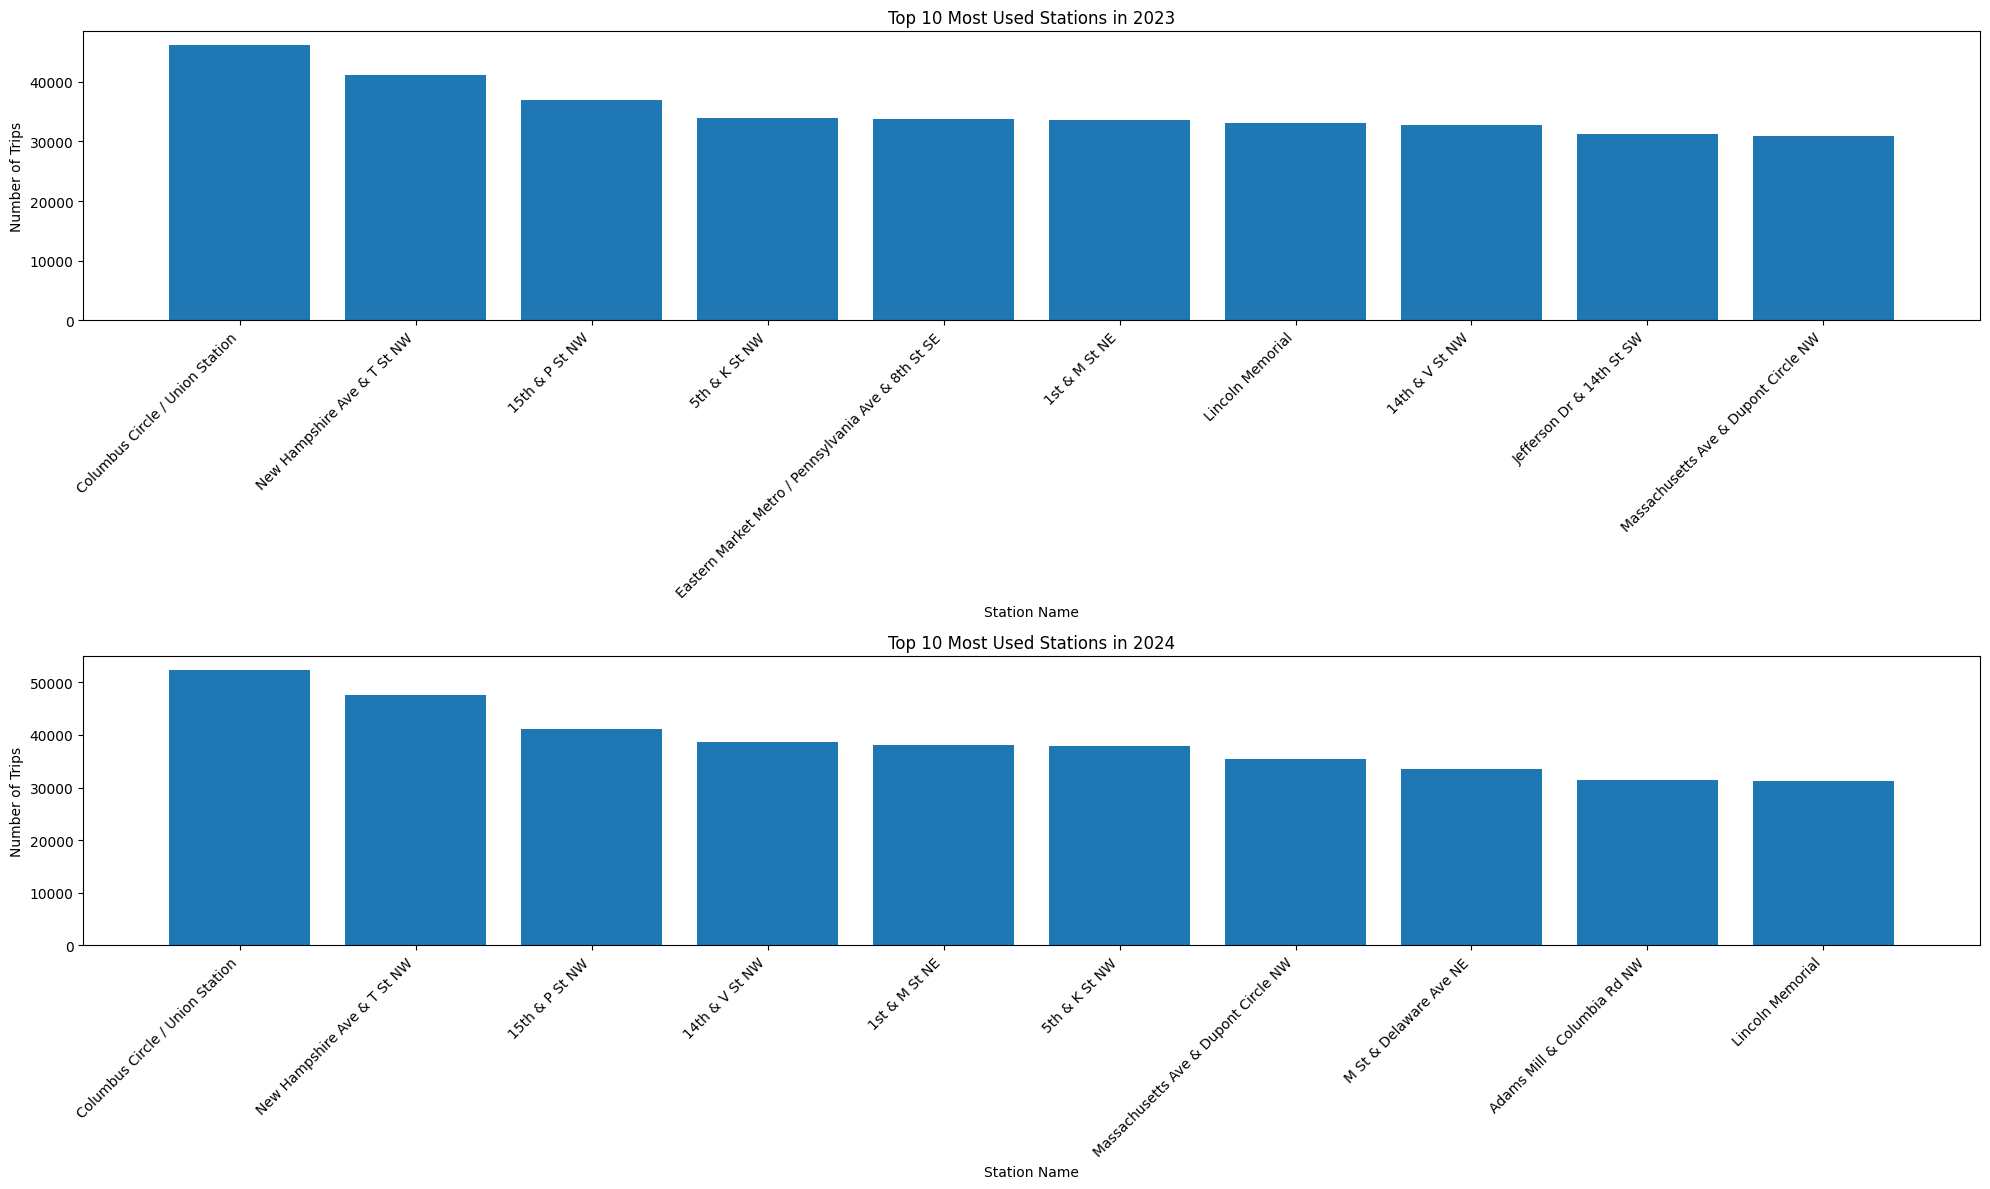

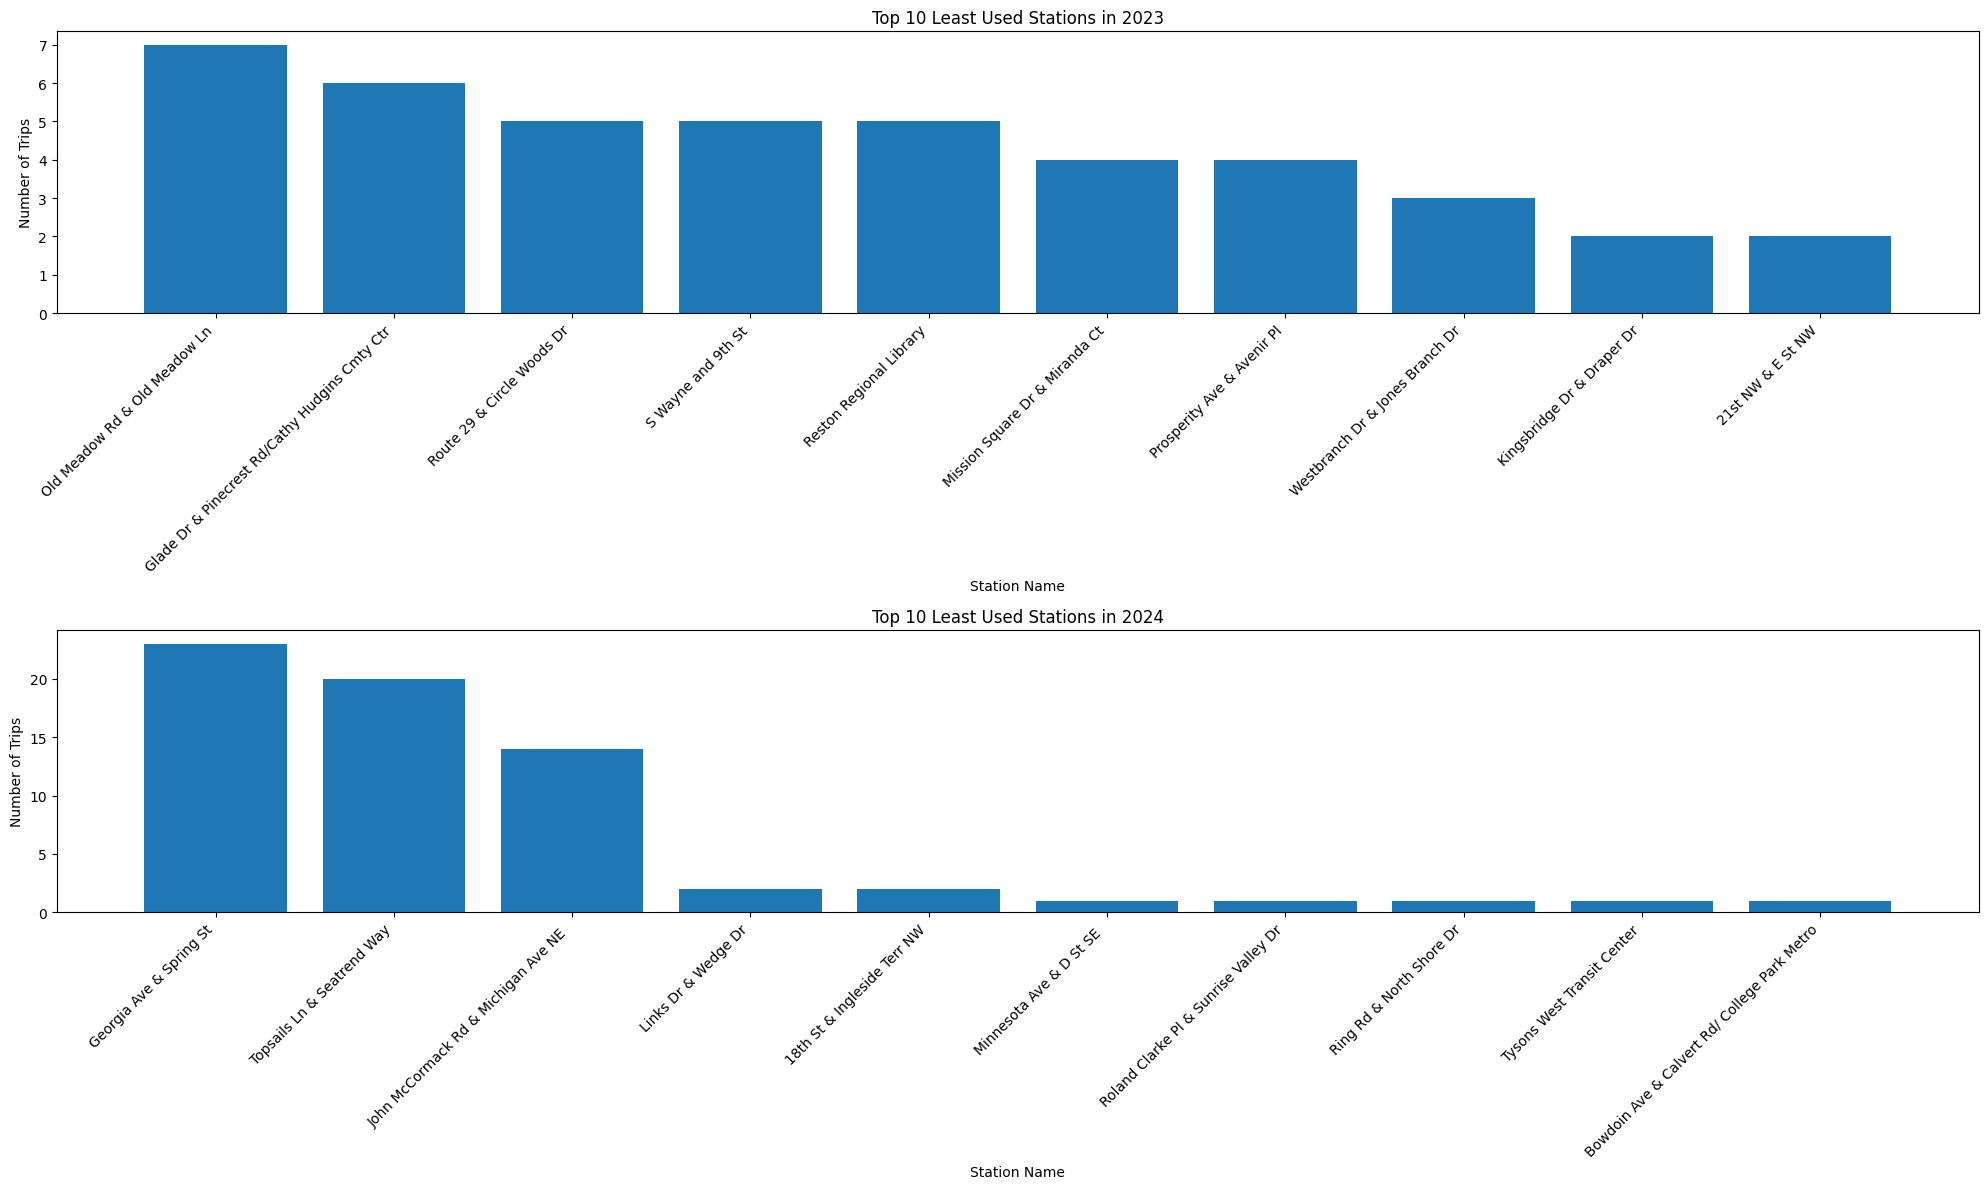

In [21]:
#Author: Ricardo Hernandez
#NOTE/Lesson: This cell was a bit of a challenge because I initally placed all of my code in one/two
#methods, and as a result, graphs appeared when all I wanted was a return value.
#To preserve readability, I'm only using the most used stations for 2 years rather than 2020-2024

def get_notable_stations(df, year, least_used = False, num_stations = 10):
    #Gets the head or tail of stations in a dataframe. This method is only intended to be called by other
    #method
    #Input - df: dataframe to analyze
    #Input - year: year to analyze
    #Input - least_used: True if least used stations are desired. Default behavior is false and returns most
    #used stations.

    #Specify the year
    df_year = df[df['Year'] == year]

    #NOTE: Even though only start stations are being counted, it doens't really matter for overall findings. The top 10
    #most/least commonly used start stations are the same as the top 10 most/least commonly used end stations, with
    #the only difference being position inside the top 10
    #Count the frequency of each station
    station_counts = df_year['start_station_name'].value_counts()

    #Return the top 10 most or least used stations
    return (station_counts.head(num_stations) if least_used is False else station_counts.tail(num_stations))

def plot_station_usage(year, least_used = False):
    #Assembles plots of station usage. Calls the 
    #  get_bikeshare_stations() method to obtain the
    #stations that should be analyzed
    #Input - year: year to plot
    #Input - least_used: True if least used stations are desired. Default behavior is false and plots most
    #used stations.

    #Obtain stations to analyze
    notable_stations = get_notable_stations(df, year, least_used)
    plt.bar(notable_stations.index, notable_stations.values)
    plt.xlabel('Station Name')
    plt.ylabel('Number of Trips')
    plt.title(f'Top 10 {("Most" if least_used is False else "Least")} Used Stations in {year}')
    plt.xticks(rotation=45, ha='right') #Needed for readability

#Create a 2 * 1 figure to hold smaller grids
plt.figure(figsize=(20, 12))

#Plot for 2023
plt.subplot(2, 1, 1)
plot_station_usage(2023)

#Plot for 2024
plt.subplot(2, 1, 2)
plot_station_usage(2024)

plt.tight_layout() #Needed for readability
plt.show()

#Plot the least used stations of 2023 and 2024
#OBSERVATION: Many of these (if not all) are outside of DC

#Create a 2 * 1 figure to hold smaller grids
plt.figure(figsize=(20, 12))

#Plot for 2023
plt.subplot(2, 1, 1)
plot_station_usage(2023, True)

#Plot for 2024
plt.subplot(2, 1, 2)
plot_station_usage(2024, True)


plt.tight_layout()
plt.show()

## Q: What are the least and most commonly used Capital Bikeshare stations?
##### A: See above graphs. For readability reasons, only 2023 & 2024 are displayed. Besides displaying the stations and ranking their usage, these graphs show that the most used Capital Bikeshare stations are in city limits of Washington, DC while the least used stations are nearly always in the suburbs of Maryland and Virginia.

In [22]:
#Author: Ricardo Hernandez
#NOTE: There's a question somewhere asking what I would do if I had another month to work.
#I would incorporate the WalkScore API, but unfortunately I did not know that I had to request
#access until it was too late
api_key = "f4ec5f6332be467aa220d3075093b0e6"
#According to the Federal Highway Administration and the Dept of Transportation, most people
#are willing to walk 0.25 - 0.5 miles for a bus stop
#The value of this float is passed to the WMATA bus stop search API
busradius =  402.336 #402.336meters = 0.25miles

def get_bikeshare_station_info(df, year, least_used = False):
    #Gets the geographic information of a dataframe of stations. Calls the get_notable_stations method
    #to obtain the stations that should be analyzed
    #Input - df: dataframe to analyze
    #Input - year: year to analyze
    #Input - least_used: True if least used stations are desired. Default behavior is false and analyzes most
    #used stations.
    #Returns - a dictionary in the format {'Station Name' : [Lat, Long]}

    #Obtain stations to analyze
    notable_stations = get_notable_stations(df, year, least_used)
    stations = notable_stations.keys().tolist()
    stationdict = {
        #Format: Station Name : [Lat, Lon]
    }

    #Begin filling dictionary
    for station in stations:
        #Create a dataframe with only the stations of interest
        station_df = df[df['start_station_name'] == station]
        #Update dictionary with name and geographic info
        stationdict[station] = [station_df['start_lat'].iloc[0], station_df['start_lng'].iloc[0]]

    return stationdict

def get_train_station_info():
    #Calls WMATA API to get the names and coordinates of all metrorail stations
    #Returns: A dictionary of train stations in the format
    #'Name' : [Latitude, Longitude]

    query_params = {
        "Cache-Control": 'no-cache',
        "api_key": api_key
    }
    main_url = " https://api.wmata.com/Rail.svc/json/jStations"

    #fetching data in json format
    res = requests.get(main_url, params=query_params)
    stations = res.json()["Stations"]

    #Create dictionary
    train_stations = {

    }

    #Update dictionary
    for station in stations:
        latlong = [station["Lat"], station["Lon"]]
        train_stations.update({station["Name"] : latlong})
    
    return train_stations

def get_bus_stop_info(lat, long, radius):
    #Calls WMATA API to get the number of bus stops within a certain radius of a given latitude longitude point
    #Input: lat - the latitude to check
    #Input: long - the longitude to check
    #Input: radius - the radius to check
    #Returns: An integer representing the number of bus stops within specified radius

    query_params = {
        "Cache-Control": 'no-cache',
        "api_key": api_key,
        "Lat": lat,
        "Lon" : long,
        "Radius" : radius
    }
    main_url = " https://api.wmata.com/Bus.svc/json/jStops"

    #fetching data in json format
    res = requests.get(main_url, params=query_params)
    stops = res.json()["Stops"]

    #Count stops
    numstops = 0
    for stop in stops:
        numstops += 1

    return numstops

def get_station_transportation_info(bikeshare_stations, train_stations):
    #Generates a list of transportation information surrounding each station in a dictionary of stations
    #Input: bikeshare_stations - dictionary of bikeshare stations with the format 'Name' : [Latitude, Longitude]
    #Input: train_stations - dictionary of train stations with the format 'Name' : [Latitude, Longitude]
    #Returns: A dictionary in the format 'Name' : [Distance to nearest train station, Name of closest train station, Number of nearby bus stops]

    #Dictionary for transportation info
    transportation_info = {

    }
    #Holds the current train station name of interest as loop iterates
    train_station_name = ""

    #Loop through each of the given bikeshare stations
    for bikeshare_station in bikeshare_stations:
        #Reset lowest distance for next iteration of bikeshare station
        low = 999999
        #Loop through each train station for each bikeshare station
        for train_station in train_stations:
            #Calculate distance in miles between current bikeshare station and current train station
            distance = round(haversine(bikeshare_stations[bikeshare_station], train_stations[train_station], unit="mi"),2)
            #Update information of closest train station
            if distance < low:
                low = distance
                train_station_name = train_station
        #Find number of bus stops near current bikeshare station
        lat = bikeshare_stations[bikeshare_station][0]
        long = bikeshare_stations[bikeshare_station][1]
        numstops = get_bus_stop_info(lat , long, busradius)
        #This line makes my code slower but it was the only way I could call the API without being rate limited
        time.sleep(0.25)
        #Update transportation info dictionary
        transportation_info[bikeshare_station] = [low, train_station_name, numstops]

    return transportation_info

def print_summary(year, least_used = False):
    #Prints a summary of nearby transportation information.
    #Depends on the following methods: get_bikeshare_station_info(), get_train_station_info, get_station_transportation_info(), and by exentsion
    #get_bus_stop_info()
    #Input: year - year to summarize
    #Input: least_used - False or empty if most used stations should be summarized. True if least used stations 
    #should be summarized

    bikeshare_stations = get_bikeshare_station_info(df, year, least_used)
    train_stations = get_train_station_info()
    station_transportation_info = get_station_transportation_info(bikeshare_stations, train_stations)

    print(f"---TRANSPORTATION OPTIONS FOR {'LEAST' if least_used == True else 'MOST'} USED BIKESHARE STATIONS OF {year}---")
    table = []

    for bikeshare_station in station_transportation_info:
        distance = station_transportation_info[bikeshare_station][0]
        bus_stops = station_transportation_info[bikeshare_station][2]
        name = station_transportation_info[bikeshare_station][1]
        table.append([bikeshare_station, f"{distance} miles", name, bus_stops])

    table_headers = ["Bikeshare Station", "Distance to Metrorail", "Closest Metro Station", "Bus Stops"]
    print(tabulate(table, headers=table_headers))
    

#Print Most used 2024 info
print_summary(2023)
print()

#Print Most used 2023 info
print_summary(2024)
print()

#Print Least used 2024 info
print_summary(2023,True)
print()

#Print Least used 2024 info
print_summary(2024, True)
print()

---TRANSPORTATION OPTIONS FOR MOST USED BIKESHARE STATIONS OF 2023---
Bikeshare Station                                    Distance to Metrorail    Closest Metro Station                               Bus Stops
---------------------------------------------------  -----------------------  ------------------------------------------------  -----------
Columbus Circle / Union Station                      0.11 miles               Union Station                                              12
New Hampshire Ave & T St NW                          0.5 miles                U Street/African-Amer Civil War Memorial/Cardozo           14
15th & P St NW                                       0.49 miles               Dupont Circle                                              21
5th & K St NW                                        0.25 miles               Mt Vernon Sq 7th St-Convention Center                      18
Eastern Market Metro / Pennsylvania Ave & 8th St SE  0.03 miles               Eastern Mark

## Q: How do transit options differ in the areas surrounding the least and most used stations?
##### A: The above tables show that Capital Bikeshare stations that are close (typically half a mile or less) to a rail station and/or have a considerable number of nearby bus stops perform better than those that aren't and/or don't.
##### The tables also reveal that bikeshare stations near the Vienna/Fairfax-GMU metro station consistently performed poorly. Vienna/Fairfax-GMU was the closest metro station to 3/10 of the 10 least used Capital Bikeshare stations of 2023.
##### Finally, the tables reveal that Capital Bikeshare stations in Virginia perform worse than those in DC and Maryland. For the "Closest Metro Station" column of the two least used bikeshare station tables, every metro station is in Virgina except for Columbia Heights (DC), Silver Spring (MD), and College Park-U of Md (MD).

---WORDCLOUD FOR MOST POPULAR BIKESHARE STATIONS (2020 - 2024)---


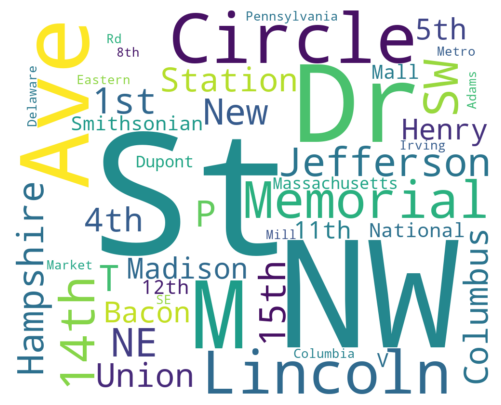

---WORDCLOUD FOR LEAST POPULAR BIKESHARE STATIONS (2020 - 2024)---


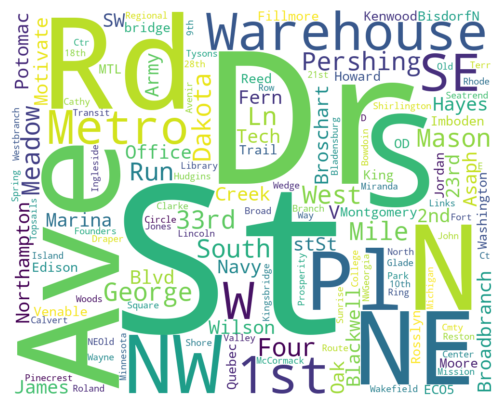

In [23]:
#Author: Ricardo Hernandez
#Create wordcloud of most and least used station names
most_used_stations = ""
least_used_stations = ""


#Loop through 2020 - 2024
for i in range(5):
    #Create strings of station names
    most_used_stations += " ".join(str(station) for station in list(get_bikeshare_station_info(df, (2020 + i)).keys()))
    least_used_stations += " ".join(str(station) for station in list(get_bikeshare_station_info(df, (2020 + i), True).keys()))

#These terms are grouped together in the dataset, probably by accident
most_used_stations = most_used_stations.replace("NWColumbus", "NW Columbus")
most_used_stations = most_used_stations.replace("NWLincoln", "NW Lincoln")

#Create word cloud object
wc = WordCloud(
    width = 1000,
    height = 800,
    background_color ='white',
    collocations = False #There are duplicates in the wordcloud without this line
)

#Generate and show wordcloud
print("---WORDCLOUD FOR MOST POPULAR BIKESHARE STATIONS (2020 - 2024)---")
plt.figure(figsize=(8, 5))
plt.imshow(wc.generate(str(most_used_stations)), interpolation='bilinear')
plt.axis("off")
plt.show()

print("---WORDCLOUD FOR LEAST POPULAR BIKESHARE STATIONS (2020 - 2024)---")
plt.figure(figsize=(8, 5))
plt.imshow(wc.generate(str(least_used_stations)), interpolation='bilinear')
plt.axis("off")
plt.show()

## Q: Can any patterns be observed in the names of the least and most used stations?
##### A: Looking at the wordclouds, a few patterns can be observed.
- Northwest DC (NW) seems to have the highest ridership of any of the four quadrants. Northwest DC has fewer rail transit options than the other quadrants, with only one metro line runnning through that section of the city.
- Southeast DC (SE) is a noticeably large word in the least used station wordcloud. This indicates very low ridership in the area.
- 4th, 5th, 12th, 14th, and 15th street all appear in the most used stations without appearing in the least used. This is not true for 1st street.
- M, P, and T street all appear in the most used stations without appearing in the least used. This is not true for V street.
- Roads (Rd) are very unpopular for Capital Bikeshare stations. Note that DC has few roads that explicitly end in "Rd," and most that do lead out of the city.
- The wordcloud for the least used stations is much denser than the wordcloud for the most used stations. This suggests the least used stations change much more frequently than the most used.

### Questions from Nataliia Padilla

#### Question #1: What type of bicycle is the most popular? Is the trend for bicycle type changing more towards electric bikes ? – This will allow us to see if more charging stations are needed or if classic bikes are more popular we can recommend reduction of investments on more expensive electric bikes.


In [ ]:
df['rideable_type'].unique()

array(['docked_bike', nan, 'electric_bike', 'classic_bike'], dtype=object)

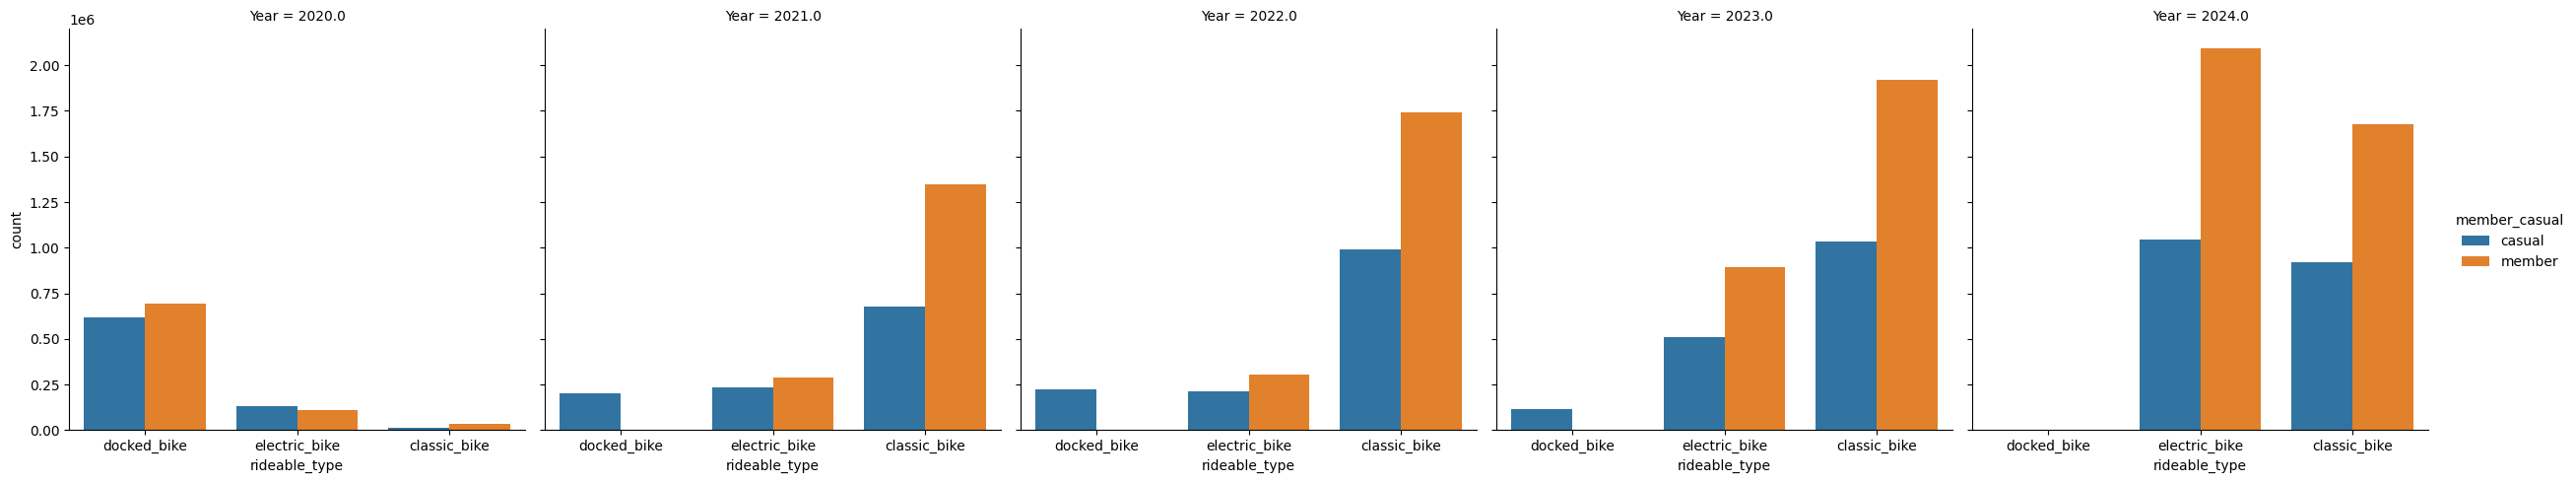

In [ ]:
#Author: Nataliia Padilla
sns.catplot(x ='rideable_type', data = df, kind = 'count', col = 'Year', hue = 'member_casual')
plt.show()

#### Conclusion: 
Classic bikes were the most popular type of bikes for rent at Capital Bikeshare in 2021 - 2023. However already in 2024 we can see that electric bikes become more popular than classic ones. At the same time popularity of docked bikes dicreased over the years (we do not have all the data for 2020, but can clearly see that docked bikes were the majority that year). Introduciton of electric scooters and increasing popularity of electric bikes show that users that rent bikes tend to prefer renting 'non traditional', electric transportation types. 
Member users tend to have more trips in all categories.

#### Question #2: Boxplot of ride length depending on the membership type

Text(0.5, 1.0, 'Boxplot of Ride Length Distribution')

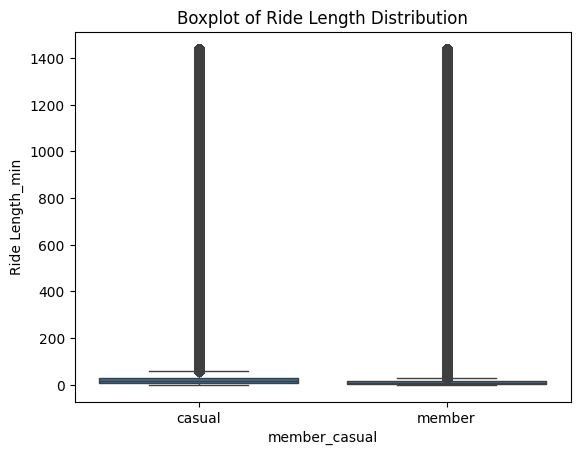

In [ ]:
#Author: Nataliia Padilla
sns.boxplot(x = df['member_casual'], y = df['Ride Length_min'])
plt.title('Boxplot of Ride Length Distribution')

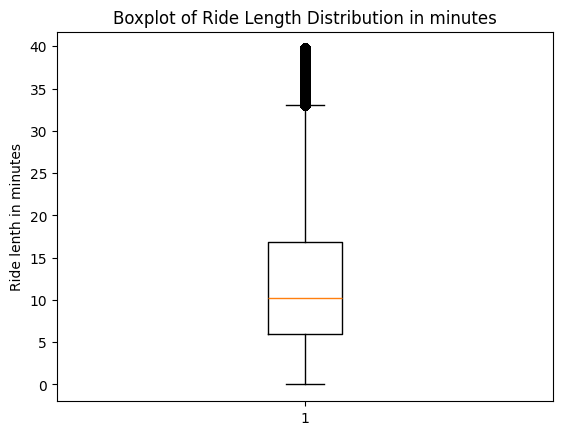

In [ ]:
#Author: Nataliia Padilla
#remove the outliers
q_1 = df['Ride Length_min'].quantile(0.25)
q_2 = df['Ride Length_min'].quantile(0.75)
iqr = q_2 - q_1
low_outliers = q_1 - 1.5 * iqr
upp_outliers = q_2 + 1.5 * iqr
df_no_outliers = df[(df['Ride Length_min'] >= low_outliers) & (df['Ride Length_min'] <= upp_outliers)]
plt.boxplot(df_no_outliers['Ride Length_min'])
plt.title('Boxplot of Ride Length Distribution in minutes')
plt.ylabel('Ride lenth in minutes')
plt.show()

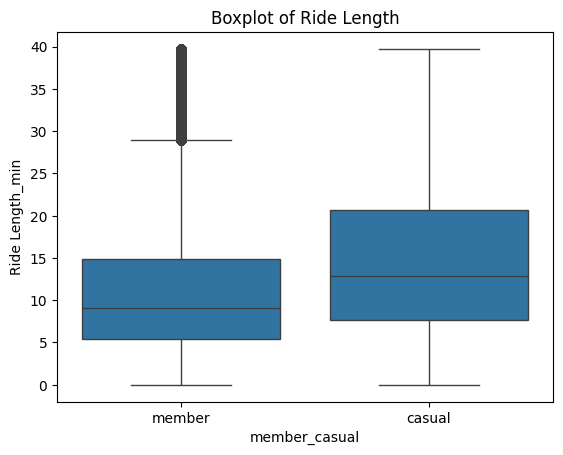

In [ ]:
#Author: Nataliia Padilla
sns.boxplot(x = df_no_outliers['member_casual'], y = df_no_outliers['Ride Length_min'], )
plt.title('Boxplot of Ride Length')
plt.show()

We can see that on average casual users tend to ride longer (both mean and 75th percentile are higher). 
Disclaimer : most of the outliers were removed for the visualisation purposes. 

In [ ]:
#Author: Nataliia Padilla
#find median for ride length for members and for casual riders
df_member = df[df['member_casual'] == 'member']
df_casual = df[df['member_casual'] == 'casual']
memb_med_ride = np.median(df_member['Ride Length_min'])
cas_med_ride = np.median(df_casual['Ride Length_min'])
print(f'Median ride length for members is {memb_med_ride}')
print(f'Median ride length for casual users is {cas_med_ride}')


Median ride length for members is 9.366666666666667
Median ride length for casual users is 15.383333333333333


In [ ]:
#Author: Nataliia Padilla
#find number of trips made by members and casual users in 2024 ( we do not have data for all the year yet, but will use it for illustration purposes
numb_trips_memb = len(df_member[df_member['Year']==2024])
numb_trips_cas = len(df_casual[df_casual['Year']==2024])
print(f'Number of trips made by members in 2024 is {numb_trips_memb}')
print(f'Number of trips made by casual users in 2024 is {numb_trips_cas}')

Number of trips made by members in 2024 is 3773451
Number of trips made by casual users in 2024 is 1962965


In [31]:
#Author: Nataliia Padilla
#sales for a min ride (no initial payments applied) from casual riders (price used will be $0.1 average per minute for classic and electric bikes
cas_s =  numb_trips_cas * 0.1 * cas_med_ride
memb_s = numb_trips_memb * 0.1 * memb_med_ride
print(f'Sales from per minute ride for casual users in 2024 : ${cas_s.round(2)}')
print(f'Sales from per minute ride per member users in 2024 : ${memb_s.round(2)}')

Sales from per minute ride for casual users in 2024 : $3019694.49
Sales from per minute ride per member users in 2024 : $3534465.77


### Conclusion: 
We can see that member riders tend to have mre trips that are shorter. Condifering only sales from per minute ride we can see that memeber users are more profitable for the company.

### Question #3:Does Capital Bikeshare's recent news tend to be positive, negative or neutral ( descriptive)?

#### Date : 12/09/2024 - 12/10/2024


In [32]:
#Author: Nataliia Padilla
#Tutorial https://squatsstreak.medium.com/guide-to-use-news-api-in-5-minutes-for-free-23d66302dc41
url = ('http://newsapi.org/v2/everything?' #search everything
       'q=Capital Bikeshare&' 
       'from=2024-12-09'#from date
       'to=2024-12-10'#to date
       #'domains=bbc.co.uk&'#domains that we want
       'domains=com&'#
       'language=en&'#choose your language
       'sortBy=relevancy&'#if we want to sort by popularity,relevancy or publishedAt
       'pageSize=30&' #if we want the number of articles default is 20 and maximum is 100
       'apiKey=4ec68a27aa0c464489bca233ec260184') 

#create request to get news article from newsapi
response = requests.get(url)


In [33]:
#test the connection
response

<Response [200]>

In [34]:
#create json format
news_cb=response.json()
news_cb

{'status': 'ok',
 'totalResults': 4,
 'articles': [{'source': {'id': None, 'name': 'Planetizen.com'},
   'author': 'Diana Ionescu',
   'title': 'DC Bike Share Growing Fast, But Regional Gaps Remain',
   'description': 'DC Bike Share Growing Fast, But Regional Gaps Remain\nDiana Ionescu\nTue, 12/03/2024 - 08:00\n\n\n \n Primary Image\r\n\n \n\n\n\r\n\n \n\n\n \n Primary Image Caption\r\n\n A Capital Bikeshare station in Bethesda, Maryland.\r\n\n \n\n\n The Washington, D.C.-area Capital Bikeshare (CaBi)…',
   'url': 'https://www.planetizen.com/news/2024/12/132977-dc-bike-share-growing-fast-regional-gaps-remain',
   'urlToImage': 'https://www.planetizen.com/files/images/Capital_Bikeshare_47th_Elm_Bethesda_MD_20210410_160509_1_crop.jpg',
   'publishedAt': '2024-12-03T16:00:00Z',
   'content': 'The Washington, D.C.-area Capital Bikeshare (CaBi) system is seeing record-breaking ridership, with the number of rides jumping almost 50 percent between October 2023 and October 2024.\r\nAccording t

In [35]:
#Author: Nataliia Padilla
#Calculate the sentiment polarity score
articles_cb = news_cb.get('articles', [])
scores_cb = []
for article in articles_cb:
    title = article['title']
    description = article['description']
    url = article['url']
    text = title + ' ' + description
    
    blob = TextBlob(text)
    score = blob.sentiment.polarity
    scores_cb.append(score)

print('Sentiment scores for the last news fetched for Capital Bikeshare are:\n')
print(scores_cb)

#Average of the list is :
average_sentiment_cb = sum(scores_cb) / len(scores_cb)
print(f'\nAverage sentiment polarity score for the news on Capital Bikeshare is {average_sentiment_cb}')

Sentiment scores for the last news fetched for Capital Bikeshare are:

[0.30000000000000004, 0.6666666666666666, -0.16, 0.010416666666666664]

Average sentiment polarity score for the news on Capital Bikeshare is 0.20427083333333332


#### Short explanation:
In sentiment analysis using TextBlob, polarity refers to the measure of how positive or negative a given text is. It is a numerical value that indicates the sentiment expressed in the text on a scale from -1 to +1, where:

+1 indicates a very positive sentiment.

0 indicates a neutral sentiment, meaning the text doesn't express any strong emotions or opinions.

-1 indicates a very negative sentiment.

### Conclusion
Sentiment analysis of the news for Capital Bikeshare shows us that majority of the recent news about Capital Bikeshare and bicycling in general are positive. However the value is only 20%, which means that Capital Bikeshare needs to improve current media strategy and brand image.

### Q4: What would be the wordcloud for CB  ( based on previously collected news)?

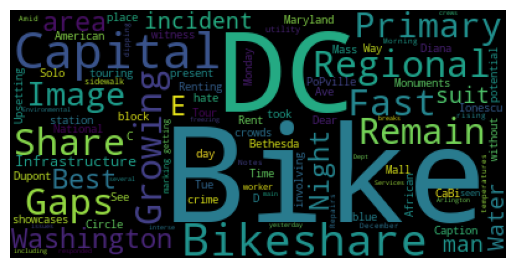

3 capital
3 bikeshare
3 bike
2 water
2 washington,
2 suit
2 share
2 remain
2 regional
2 primary


In [36]:
#Author: Nataliia Padilla
text_cb = ''
articles_cb = news_cb.get('articles', [])
for article in articles_cb:
    title = article['title']
    description = article['description']
    url = article['url']

    # Combine the title and description for sentiment analysis
    text = title + ' ' + description
    text_cb += text
#WordCloud for Capital Bikeshare
wordcloud = WordCloud().generate(text_cb)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()
    
stop_words = ['a', 'an', 'another', 'any', 'certain', 'each', 'every', 'her', 'his', 'its', 'its', 'my', 'no', 
              'our', 'some', 'that', 'the', 'their', 'this', '#coordinating conjunctions', 'and', 'but', 'or', 'yet', 
              'for', 'nor', 'so', '#preposition', 'as', 'aboard', 'about', 'above', 'across', 'after', 'against', 
              'along', 'around', 'at', 'before', 'behind', 'below', 'beneath', 'beside', 'between', 'beyond', 'but', 
              'by', 'down', 'during', 'except', 'following', 'for', 'from', 'in', 'inside', 'into', 'like', 'minus', 
              'minus', 'near', 'next', 'of', 'off', 'on', 'onto', 'onto', 'opposite', 'out', 'outside', 'over', 'past', 
              'plus', 'round', 'since', 'since', 'than', 'through', 'to', 'toward', 'under', 'underneath', 'unlike', 
              'until', 'up', 'upon', 'with', 'without']

counts = {}
sum_words = 0
for word in text_cb.split():
    word = word.lower()
    if word.isnumeric(): #handle numbers
        word = num2words(int(word))
    sum_words +=1
    if word in stop_words:
        pass
    elif word not in counts:
        counts[word] = 1
    else:
        counts[word] += 1
lst = list()
for key, val in counts.items():
    lst.append((val, key))
                
lst.sort(reverse = True)
            
for key, val in lst[:10]:
    print(key, val)

### Conclusion
From the Word Cloud for Capital Bikeshare news we can see that majority of the words used are neutral, with few words indicating negative connotation (for example Incident, Upsetting) and some positive words ( like Growing, Fast).